# Technology stock signals: reproducible research notebook

Compare logistic regression, random forest, and an optional LSTM on next-day direction. The default run uses fictional, synthetic prices so the full classical workflow can run offline. The payoff simulation is a teaching approximation, not an options pricing model or evidence of profitability.

## Setup

Install `requirements.txt` from the repository root. TensorFlow is optional; install `requirements-lstm.txt` and set `RUN_LSTM=True` to enable the sequence model.

In [1]:
# Install dependencies from your terminal before starting this notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.pipeline import Pipeline
from stock_features import fetch_data, engineer_features, time_based_split, build_sequences, FEATURE_COLS
plt.style.use('seaborn-v0_8')
pd.options.display.float_format = '{:.4f}'.format

## Configuration
Feel free to tweak the ticker list, date range, and modeling hyperparameters.

In [3]:
USE_LIVE_DATA = False
RUN_LSTM = False

# Universe of large-cap tech names
TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "TSLA", "AMD", "AVGO", "CRM"]

START_DATE = "2016-01-01"
END_DATE = "2025-12-31"  # Explicit end date for a documented live-data experiment

# Modeling parameters
LOOKBACK_DAYS = 10  # sequence length for the LSTM
VAL_SIZE = 0.2
TEST_SIZE = 0.15
RANDOM_STATE = 42

# Trading parameters
TRANSACTION_COST_BPS = 10  # 1bp ~ 0.01%
SLIPPAGE_BPS = 5  # 0.05% per trade
OPTION_PREMIUM = 0.01  # 1% premium cost for the simplified options-style bet
CALL_DELTA = 0.6  # sensitivity of payoff to underlying price moves
PUT_DELTA = -0.5
PROB_BUY_THRESHOLD = 0.55
PROB_SELL_THRESHOLD = 0.45


## Data source

The default fixture contains fictional `DEMO_A`, `DEMO_B`, and `DEMO_C` prices. Live mode downloads the configured tickers with explicit adjustment settings and caches the exact CSV used by this run.

In [4]:
if USE_LIVE_DATA:
    prices = fetch_data(TICKERS, START_DATE, END_DATE)
    Path('data/downloads').mkdir(parents=True, exist_ok=True)
    prices.to_csv('data/downloads/prices.csv', index=False)
else:
    prices = pd.read_csv('data/sample_prices.csv', parse_dates=['date'])
print('Data source:', 'yfinance' if USE_LIVE_DATA else 'synthetic fixture')
print(prices.head())

Data source: synthetic fixture
        date  ticker     open     high      low    close  adj close  volume
0 2025-01-01  DEMO_A 100.0000 100.7489  99.7000 100.4476   100.4476  427285
1 2025-01-02  DEMO_A 100.4476 101.8334 100.1463 101.5288   101.5288  319439
2 2025-01-03  DEMO_A 101.5288 103.2038 101.2242 102.8951   102.8951  200734
3 2025-01-06  DEMO_A 102.8951 103.2038 100.7533 101.0565   101.0565  147088
4 2025-01-07  DEMO_A 101.0565 101.5616 100.7533 101.2578   101.2578  458738


## Feature Engineering
We build simple yet intuitive features:

* Daily returns and next-day returns (target).
* Rolling mean/volatility of returns.
* Momentum proxies (rolling max/min, RSI-like feature).
* Volume z-score.

Each ticker is processed independently and then concatenated.

In [5]:
features = engineer_features(prices)
print(features[['date', 'target_date', 'ticker', 'return', 'target']].head())

        date target_date  ticker  return  target
0 2025-01-28  2025-01-29  DEMO_A  0.0063       1
1 2025-01-29  2025-01-30  DEMO_A  0.0306       0
2 2025-01-30  2025-01-31  DEMO_A -0.0069       0
3 2025-01-31  2025-02-03  DEMO_A -0.0111       1
4 2025-02-03  2025-02-04  DEMO_A  0.0161       0


## Chronological partitions

All tickers on a date stay together. Training and validation rows whose next-day labels cross into the following partition are purged. Features are available after each day closes; the label is the following observed day.

In [6]:
train_df, val_df, test_df = time_based_split(features, TEST_SIZE, VAL_SIZE)
print('Train / validation / test rows:', len(train_df), len(val_df), len(test_df))
assert train_df.target_date.max() < val_df.date.min()
assert val_df.target_date.max() < test_df.date.min()

Train / validation / test rows: 282 69 63


## Classical Machine Learning Models
We treat each day-ticker observation as a tabular feature vector. Ticker is one-hot encoded to allow models to learn per-name effects.

In [7]:
FEATURE_COLS = ['ret_ma_5', 'ret_ma_10', 'ret_std_10', 'high_roll_10', 'low_roll_10', 'volume_z', 'rsi', 'return']

# One-hot encode ticker
train_X = pd.get_dummies(train_df[['ticker'] + FEATURE_COLS], columns=['ticker'])
val_X = pd.get_dummies(val_df[['ticker'] + FEATURE_COLS], columns=['ticker'])
test_X = pd.get_dummies(test_df[['ticker'] + FEATURE_COLS], columns=['ticker'])

# Align dummy columns
train_X, val_X = train_X.align(val_X, join='left', axis=1, fill_value=0)
train_X, test_X = train_X.align(test_X, join='left', axis=1, fill_value=0)

target_train = train_df['target']
target_val = val_df['target']
target_test = test_df['target']

models = {}

log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=500, class_weight='balanced'))
])
log_reg.fit(train_X, target_train)
models['Logistic Regression'] = log_reg

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_clf.fit(train_X, target_train)
models['Random Forest'] = rf_clf


## Optional sequence model

Each sequence ends on the feature date associated with its label. Per-ticker scalers are fit on training rows and reused for validation/test. Original row indices are retained for prediction alignment. This demo starts each sequence window inside its own partition.

In [8]:
if RUN_LSTM:
    import tensorflow as tf
    from tensorflow.keras import layers, models as keras_models
    tf.keras.utils.set_random_seed(RANDOM_STATE)
    train_seq_X, train_seq_y, train_seq_indices, scalers = build_sequences(train_df, LOOKBACK_DAYS)
    val_seq_X, val_seq_y, val_seq_indices, _ = build_sequences(val_df, LOOKBACK_DAYS, scalers)
    test_seq_X, test_seq_y, test_seq_indices, _ = build_sequences(test_df, LOOKBACK_DAYS, scalers)
    lstm_model = keras_models.Sequential([
        layers.Input(shape=(LOOKBACK_DAYS, len(FEATURE_COLS))),
        layers.LSTM(32), layers.Dropout(0.2),
        layers.Dense(16, activation='relu'), layers.Dense(1, activation='sigmoid')
    ])
    lstm_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    history = lstm_model.fit(train_seq_X, train_seq_y, validation_data=(val_seq_X, val_seq_y),
                             epochs=25, batch_size=64, verbose=1,
                             callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)])
    models['LSTM'] = lstm_model
else:
    print('LSTM skipped. Set RUN_LSTM=True after installing requirements-lstm.txt to run it.')

LSTM skipped. Set RUN_LSTM=True after installing requirements-lstm.txt to run it.


## Evaluation Helpers

In [9]:
def evaluate_classifier(model, X, y_true, name):
    prob = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else model.predict(X, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)
    acc = accuracy_score(y_true, pred)
    auc = roc_auc_score(y_true, prob) if len(np.unique(y_true)) > 1 else np.nan
    print(f"{name} Accuracy: {acc:.3f}, ROC-AUC: {auc:.3f}")
    print(classification_report(y_true, pred, digits=3, zero_division=0))
    return prob

probs_test = {}
for name, model in models.items():
    X, y = (test_seq_X, test_seq_y) if name == 'LSTM' else (test_X, target_test)
    probs_test[name] = evaluate_classifier(model, X, y, name)
majority_class = int(target_train.mean() >= 0.5)
print('Training-majority baseline accuracy:', accuracy_score(target_test, np.full(len(target_test), majority_class)))

Logistic Regression Accuracy: 0.476, ROC-AUC: 0.467
              precision    recall  f1-score   support

           0      0.472     0.548     0.507        31
           1      0.481     0.406     0.441        32

    accuracy                          0.476        63
   macro avg      0.477     0.477     0.474        63
weighted avg      0.477     0.476     0.474        63

Random Forest Accuracy: 0.492, ROC-AUC: 0.498
              precision    recall  f1-score   support

           0      0.484     0.484     0.484        31
           1      0.500     0.500     0.500        32

    accuracy                          0.492        63
   macro avg      0.492     0.492     0.492        63
weighted avg      0.492     0.492     0.492        63

Training-majority baseline accuracy: 0.5079365079365079


## Feature Importance
We visualize coefficient magnitudes for logistic regression and mean decrease impurity for the random forest.

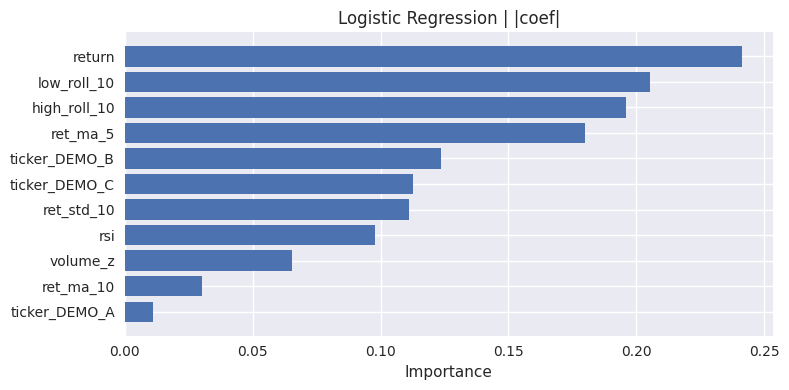

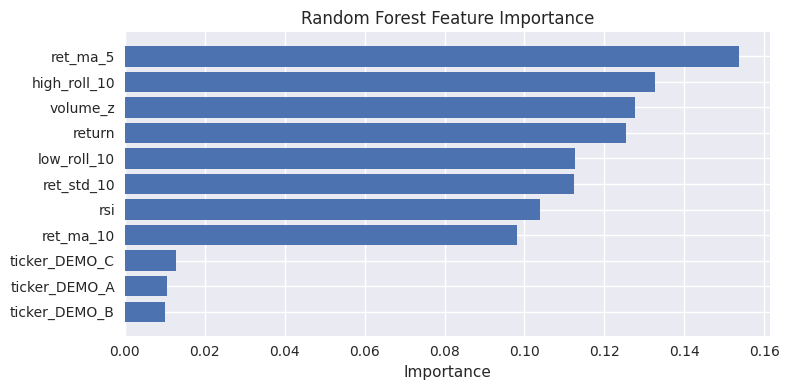

In [10]:
def plot_feature_importance(model, feature_names, title):
    plt.figure(figsize=(8,4))
    if hasattr(model, 'coef_'):
        imp = np.abs(model.coef_[0])
    else:
        imp = model.feature_importances_
    idx = np.argsort(imp)[::-1][:15]
    plt.barh(np.array(feature_names)[idx][::-1], imp[idx][::-1])
    plt.title(title)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

plot_feature_importance(log_reg['clf'], train_X.columns, 'Logistic Regression | |coef|')
plot_feature_importance(rf_clf, train_X.columns, 'Random Forest Feature Importance')


## Signal Generation
We convert predicted probabilities into discrete trading signals.

* **Buy / call-style bet:** probability > `PROB_BUY_THRESHOLD`.
* **Sell / put-style bet:** probability < `PROB_SELL_THRESHOLD`.
* Otherwise: stay flat.


In [11]:
def generate_signals(df, probs, model_name):
    signals = df[['date', 'ticker', 'next_return']].copy()
    signals['prob_pos'] = probs
    signals['signal'] = 0
    signals.loc[signals['prob_pos'] > PROB_BUY_THRESHOLD, 'signal'] = 1
    signals.loc[signals['prob_pos'] < PROB_SELL_THRESHOLD, 'signal'] = -1
    signals['model'] = model_name
    return signals

# Align test probabilities to dataframe rows for classical models
signals_all = []
for name in ['Logistic Regression', 'Random Forest']:
    sig = generate_signals(test_df.reset_index(drop=True), probs_test[name], name)
    signals_all.append(sig)

if RUN_LSTM:
    lstm_df = test_df.loc[test_seq_indices].reset_index(drop=True)
    signals_all.append(generate_signals(lstm_df, probs_test['LSTM'], 'LSTM'))
signals_df = pd.concat(signals_all).reset_index(drop=True)
signals_df.head()

,date,ticker,next_return,prob_pos,signal,model
0,2025-07-14,DEMO_A,-0.0120,0.3963,-1,Logistic Regression
1,2025-07-14,DEMO_B,0.0053,0.6647,1,Logistic Regression
2,2025-07-14,DEMO_C,0.0341,0.5317,0,Logistic Regression
3,2025-07-15,DEMO_A,-0.0045,0.4804,0,Logistic Regression
4,2025-07-15,DEMO_B,0.0189,0.6894,1,Logistic Regression


## Simplified Options-Style Strategy & Backtest
We approximate option payoffs using delta times the underlying return minus a fixed premium:

* **Call-like (signal = +1):** payoff = max(CALL_DELTA * return - premium, -premium)
* **Put-like (signal = -1):** payoff = max(PUT_DELTA * return - premium, -premium)

Transaction costs and slippage reduce returns each time a position is opened. We compound P&L equally weighted across tickers each day.

In [12]:
def option_payoff(ret, signal):
    if signal == 1:
        raw = CALL_DELTA * ret - OPTION_PREMIUM
    elif signal == -1:
        raw = PUT_DELTA * ret - OPTION_PREMIUM
    else:
        return 0.0
    return max(raw, -OPTION_PREMIUM)  # limited downside to premium


def backtest(signals, cost_bps=10, slippage_bps=5):
    df = signals.copy()
    df['day'] = pd.to_datetime(df['date'])
    daily_results = []
    for (day, model), g in df.groupby(['day', 'model']):
        pnl = 0
        n_trades = (g['signal'] != 0).sum()
        for _, row in g.iterrows():
            pnl += option_payoff(row['next_return'], row['signal'])
        # Apply linear costs
        total_bps = (cost_bps + slippage_bps) * n_trades
        pnl -= total_bps / 10000
        # Equal capital allocation across all tickers, including flat positions.
        daily_results.append({'date': day, 'model': model, 'pnl': pnl / len(g)})
    res = pd.DataFrame(daily_results).sort_values('date')
    res['equity'] = (1 + res['pnl']).groupby(res['model']).cumprod()
    return res

bt_results = backtest(signals_df, TRANSACTION_COST_BPS, SLIPPAGE_BPS)
bt_results.head()


,date,model,pnl,equity
0,2025-07-14,Logistic Regression,-0.0046,0.9954
1,2025-07-14,Random Forest,0.0002,1.0002
2,2025-07-15,Logistic Regression,-0.0001,0.9953
3,2025-07-15,Random Forest,-0.0039,0.9963
4,2025-07-16,Logistic Regression,-0.0111,0.9842


## Performance Comparison
We visualize equity curves and summarize key metrics like cumulative return and hit rate (fraction of profitable days).

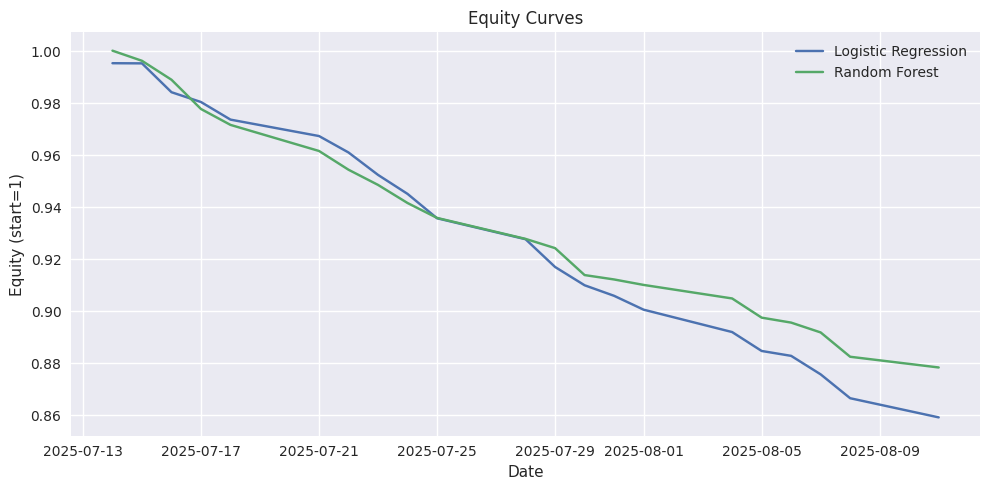

In [13]:
def summarize_backtest(bt_df):
    summaries = []
    for model, g in bt_df.groupby('model'):
        cum_return = g['equity'].iloc[-1] - 1
        hit_rate = (g['pnl'] > 0).mean()
        vol = g['pnl'].std() * np.sqrt(252)
        sharpe = (g['pnl'].mean() * 252) / (vol + 1e-9)
        summaries.append({
            'Model': model,
            'Cumulative Return': cum_return,
            'Hit Rate': hit_rate,
            'Sharpe (naive)': sharpe
        })
    return pd.DataFrame(summaries)

summary_df = summarize_backtest(bt_results)
summary_df

plt.figure(figsize=(10,5))
for model, g in bt_results.groupby('model'):
    plt.plot(g['date'], g['equity'], label=model)
plt.legend()
plt.title('Equity Curves')
plt.ylabel('Equity (start=1)')
plt.xlabel('Date')
plt.tight_layout()
plt.show()


## Interpretation and next steps

Synthetic results verify the workflow only. On real data, compare models on matching dates and observations, preserve the downloaded dataset, and document survivorship and selection bias. Optional LSTM windows use fewer rows than the classical models, so their raw summaries are not directly comparable. The simplified payoff omits actual option quotes, expiry, volatility, liquidity, and execution timing. Features use closing data and the next close-to-close return; a live strategy would also need a feasible entry price after the signal is available.